In [1]:
import pandas as pd
import numpy as np
import polars as pl
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Dendogram and VIF- Full cost basis

In [7]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_PATH = DATA_DIR / "processed" / "train.parquet"

In [8]:
train = pl.read_parquet(TRAIN_PATH)

In [9]:
full_cost_basis = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("cost_basis_"))
    .collect()
)
len(full_cost_basis)
full_cost_basis_df = full_cost_basis.to_pandas()

In [10]:
full_cost_basis_df = full_cost_basis_df.pivot(columns='metric',index='day_utc', values='value')

In [59]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

wide_cost = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("cost_basis_"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

# Drop columns with >50% NaN, fill gaps, drop constant columns
wide_cost = wide_cost.dropna(axis=1, thresh=int(0.5 * len(wide_cost)))
wide_cost = wide_cost.fillna(wide_cost.median())
wide_cost = wide_cost.loc[:, wide_cost.nunique() > 1]

print(f"Shape after cleaning: {wide_cost.shape}")


corr = wide_cost.corr(method="pearson")

dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

Shape after cleaning: (5470, 35)


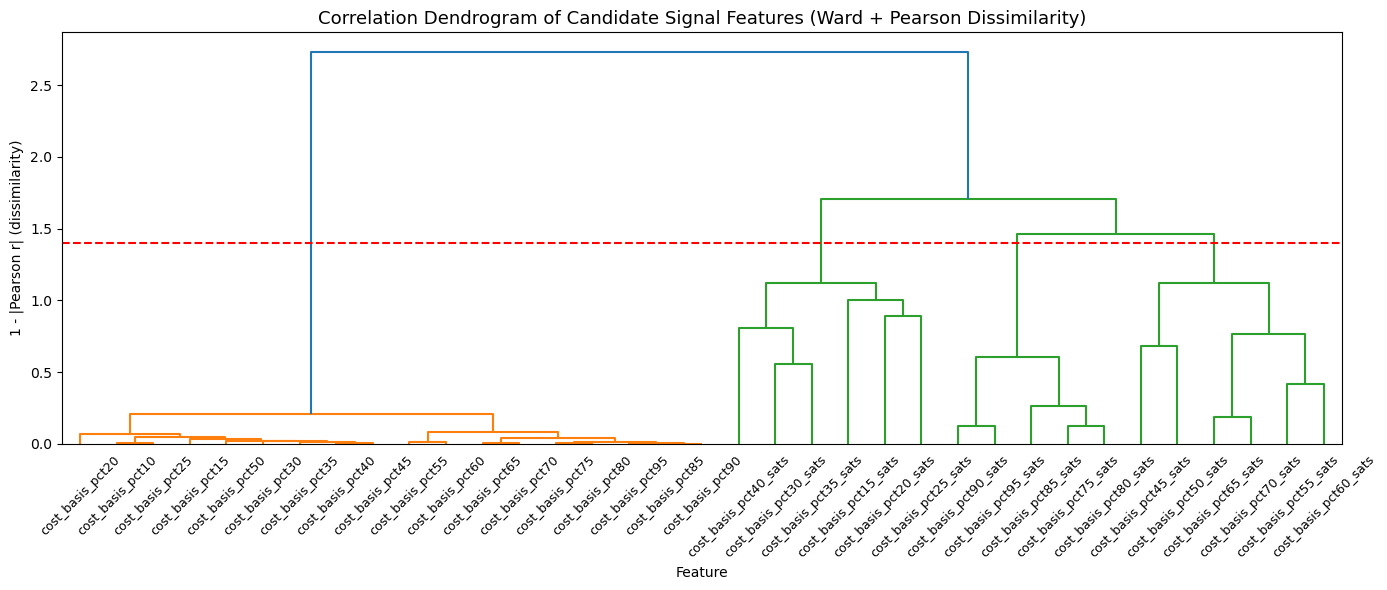

In [60]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=corr.columns.tolist(), leaf_rotation=45, leaf_font_size=9, ax=ax)
ax.set_title("Correlation Dendrogram of Candidate Signal Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=1.4, color='r', linestyle='--')
plt.tight_layout()
plt.show()

I suggest a threshold at 1.4, giving us 4 clean clusters

In [61]:
clusters_cost = fcluster(Z, t=1.4, criterion="distance")

cluster_map_cost = dict(zip(wide_cost.columns, clusters_cost))

cluster_df_cost = pd.DataFrame({
    "feature": wide_cost.columns,
    "cluster": clusters_cost
})
cluster_df_cost.head()

,feature,cluster
0,cost_basis_pct10,1
1,cost_basis_pct15,1
2,cost_basis_pct15_sats,2
3,cost_basis_pct20,1
4,cost_basis_pct20_sats,2


In [62]:
cluster_df_cost.groupby("cluster").size()

cluster
1    18
2     6
3     5
4     6
dtype: int64

In [63]:
n = cluster_df_cost["cluster"].nunique()
clusters = {}
for i in range(1, n+1):
    clusters[i] = cluster_df_cost[cluster_df_cost["cluster"] == i]["feature"].tolist()

In [64]:
high_vif = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif[i]}")


Cluster 1:
cost_basis_pct90    3340.302751
cost_basis_pct85    3136.013152
cost_basis_pct95    2304.347034
cost_basis_pct75     858.957195
cost_basis_pct80     794.469413
cost_basis_pct70     549.128335
cost_basis_pct35     470.501486
cost_basis_pct65     421.481814
cost_basis_pct60     373.742085
cost_basis_pct40     372.222952
cost_basis_pct25     354.360684
cost_basis_pct10     338.903969
cost_basis_pct45     317.428026
cost_basis_pct50     282.638424
cost_basis_pct55     259.721912
cost_basis_pct30     241.250626
cost_basis_pct20     209.689172
cost_basis_pct15     116.356658

  High VIF cols (>10): ['cost_basis_pct10', 'cost_basis_pct15', 'cost_basis_pct20', 'cost_basis_pct25', 'cost_basis_pct30', 'cost_basis_pct35', 'cost_basis_pct40', 'cost_basis_pct45', 'cost_basis_pct50', 'cost_basis_pct55', 'cost_basis_pct60', 'cost_basis_pct65', 'cost_basis_pct70', 'cost_basis_pct75', 'cost_basis_pct80', 'cost_basis_pct85', 'cost_basis_pct90', 'cost_basis_pct95']

Cluster 2:
cost_basis_pct1

In [65]:
all_high_vif_cost_basis = [col for cols in high_vif.values() for col in cols]

# Dendogram and VIF - Address Columns

In [66]:
full_address = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("addrs"))
    .collect()
)
len(full_address)
full_address_pd = full_address.to_pandas()

In [22]:
full_address_df = full_address_pd.pivot(columns='metric',index='day_utc', values='value')

In [67]:
wide_addrs = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("addrs"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

# Drop columns with >50% NaN, fill gaps, drop constant columns
wide_addrs = wide_addrs.dropna(axis=1, thresh=int(0.5 * len(wide_addrs)))
wide_addrs = wide_addrs.fillna(wide_addrs.median())
wide_addrs = wide_addrs.loc[:, wide_addrs.nunique() > 1]

print(f"Shape after cleaning: {wide_addrs.shape}")


corr = wide_addrs.corr(method="pearson")

dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

Shape after cleaning: (5471, 5057)


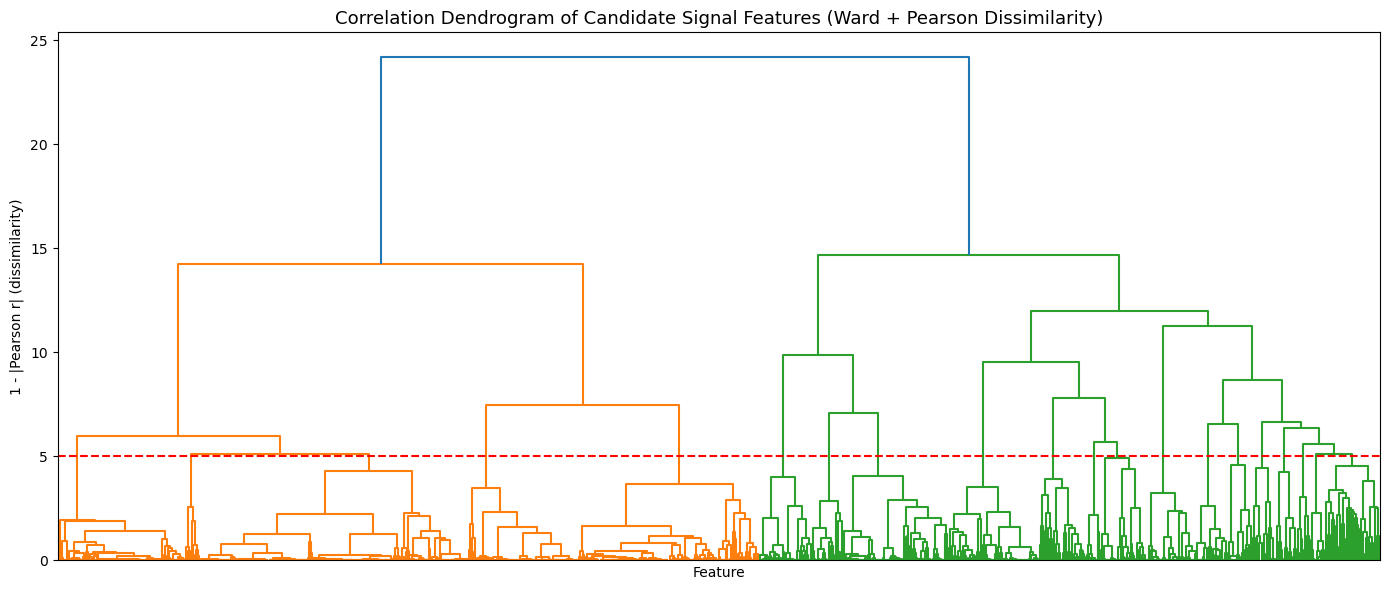

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of ADDRS Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color='r', linestyle='--')
plt.tight_layout()
plt.show()

Due to the large number of metrics in this family, I suggest using a threshold of 5. This will give us 20 clusters each with a relatively smaller subset of metrics.

In [69]:
clusters_addrs = fcluster(Z, t=5, criterion="distance")

cluster_map_addrs = dict(zip(wide_addrs.columns, clusters_addrs))


cluster_df_addrs = pd.DataFrame({
    "feature": wide_addrs.columns,
    "cluster": clusters_addrs
})
cluster_df_addrs.head()

,feature,cluster
0,addrs_above_100btc_under_1k_btc__30d_change,20
1,addrs_above_100btc_under_1k_btc__30d_change_btc,20
2,addrs_above_100btc_under_1k_btc__30d_change_usd,6
3,addrs_above_100btc_under_1k_btc_addr_count,9
4,addrs_above_100btc_under_1k_btc_addr_count_30d...,20


In [70]:
cluster_df_addrs["cluster"].value_counts().sort_index()

cluster
1      489
2       52
3     1033
4      416
5      694
6      200
7      121
8      405
9      346
10     181
11      53
12     181
13     183
14     123
15      91
16      94
17      78
18      52
19      54
20     211
Name: count, dtype: int64

In [71]:
n = cluster_df_addrs["cluster"].nunique()
clusters_addrs_dict = {}
for i in range(1, n+1):
    clusters_addrs_dict[i] = cluster_df_addrs[cluster_df_addrs["cluster"] == i]["feature"].tolist()


high_vif_addrs = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_addrs_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_addrs[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_addrs[i]}")


Cluster 1:


/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


addrs_under_10btc_supply                                                           2.006058e+13
addrs_above_100sats_under_1k_sats_supply_btc                                       2.695959e+12
addrs_above_1m_sats_under_10m_sats_sent_in_profit_14d_ema_btc                      2.032769e+12
addrs_under_100btc_supply_halved_btc                                               5.573762e+11
addrs_under_10m_sats_sent_in_profit_cumulative                                     4.341656e+11
addrs_over_10m_sats_coinblocks_destroyed_cumulative                                3.332297e+11
addrs_above_100k_sats_under_1m_sats_supply_halved_btc                              2.891650e+11
addrs_above_1m_sats_under_10m_sats_utxo_count                                      2.793536e+11
addrs_over_1btc__30d_change_btc                                                    2.696443e+11
addrs_above_100k_sats_under_1m_sats_sent_in_profit_14d_ema                         2.647774e+11
addrs_under_1k_sats_supply_halved_btc   

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


addrs_above_1k_sats_under_10k_sats_capitulation_flow                             inf
addrs_under_10k_sats_realized_loss                                               inf
addrs_above_1k_sats_under_10k_sats_value_created                                 inf
addrs_above_1k_sats_under_10k_sats_value_destroyed                               inf
addrs_under_10k_sats_loss_value_created                                          inf
addrs_under_10k_sats_loss_value_destroyed                                        inf
addrs_under_10k_sats_neg_realized_loss                                           inf
addrs_under_10k_sats_profit_flow                                                 inf
addrs_under_10k_sats_profit_value_created                                        inf
addrs_under_10k_sats_profit_value_destroyed                                      inf
addrs_under_10k_sats_realized_value                                              inf
addrs_above_1k_sats_under_10k_sats_sent_in_profit_usd            

...

addrs_under_100sats_net_realized_pnl                                                                   inf
addrs_under_100sats_net_realized_pnl_7d_ema                                                            inf
addrs_above_1sat_under_10sats_profit_value_created                                                     inf
addrs_above_1sat_under_10sats_profit_value_destroyed                                                   inf
addrs_above_1sat_under_10sats_realized_peak_regret                                                     inf
addrs_above_1sat_under_10sats_realized_profit                                                          inf
addrs_above_1sat_under_10sats_realized_profit_rel_to_realized_cap                                      inf
addrs_above_1sat_under_10sats_sell_side_risk_ratio                                                     inf
addrs_above_1sat_under_10sats_sell_side_risk_ratio_7d_ema                                              inf
addrs_above_1sat_under_10sats_sent_in

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


addrs_above_100k_sats_under_1m_sats__30d_change                        inf
addrs_under_10btc_utxo_count_30d_change                                inf
addrs_over_1btc_utxo_count_30d_change                                  inf
addrs_over_1m_sats_addr_count_30d_change                               inf
addrs_above_100k_sats_under_1m_sats__30d_change_btc                    inf
addrs_under_100k_sats__30d_change                                      inf
addrs_under_100k_sats__30d_change_btc                                  inf
addrs_under_100k_sats_addr_count_30d_change                            inf
addrs_under_100k_sats_utxo_count_30d_change                            inf
addrs_under_10m_sats__30d_change                                       inf
addrs_over_10k_sats_utxo_count_30d_change                              inf
addrs_under_10m_sats__30d_change_btc                                   inf
addrs_under_10m_sats_addr_count_30d_change                             inf
addrs_under_10m_sats_utxo

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


addrs_above_100k_btc_realized_loss                                                                2.498116e+08
addrs_above_100k_btc_realized_profit_7d_ema                                                       1.096825e+08
addrs_above_100k_btc_realized_loss_7d_ema                                                         9.793857e+07
addrs_above_100k_btc_total_realized_pnl                                                           8.004384e+07
addrs_above_10btc_under_100btc_utxo_count_30d_change                                              7.787581e+07
addrs_above_100k_btc_realized_profit                                                              6.744601e+07
addrs_above_100k_btc_realized_value                                                               6.070270e+07
addrs_above_100k_btc__30d_change                                                                  4.715947e+07
addrs_above_10sats_under_100sats_sent_in_loss_btc                                                 3.986569e+07
a

In [72]:
all_high_vif_addrs = [col for cols in high_vif_addrs.values() for col in cols]

# Dendogram and VIF - DCA Strategy

In [30]:
full_dca_family = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("dca_"))
    .collect()
)

full_dca_df = full_dca_family.to_pandas()

In [31]:
full_dca_df = full_dca_df.pivot(columns='metric',index='day_utc', values='value')
len(full_dca_df.columns)

238

Shape after cleaning: (5471, 188)


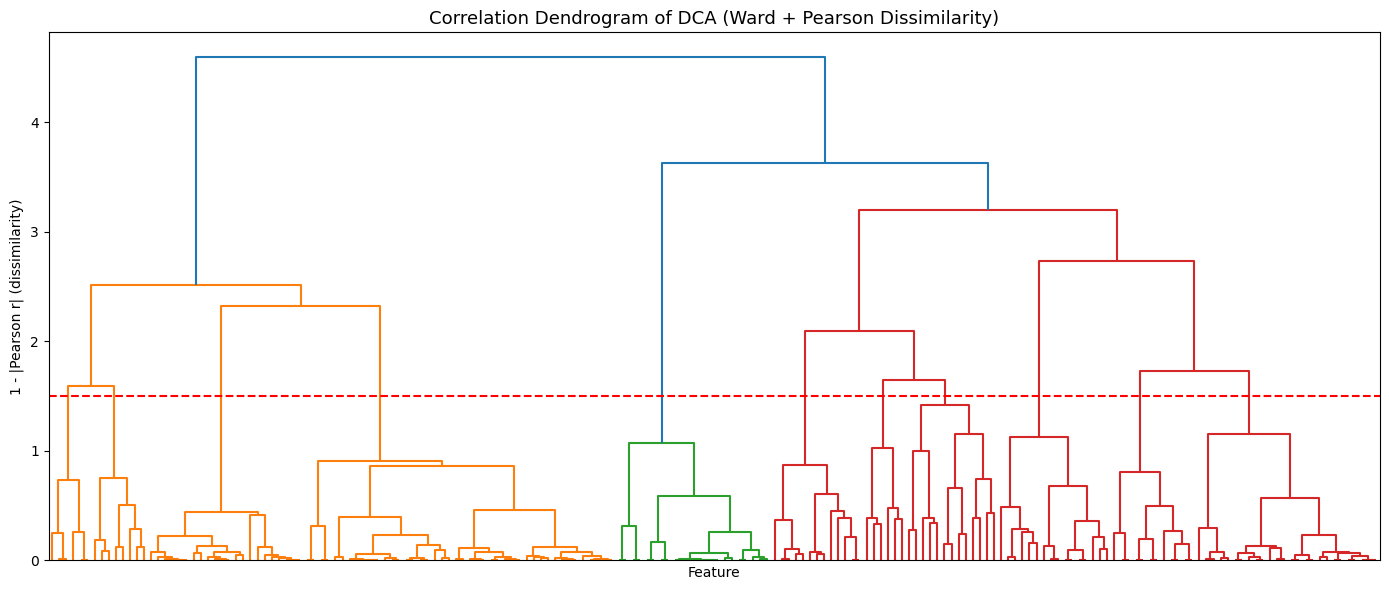

In [73]:
wide_dca = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("dca_"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

# Drop columns with >50% NaN, fill gaps, drop constant columns
wide_dca = wide_dca.dropna(axis=1, thresh=int(0.5 * len(wide_dca)))
wide_dca = wide_dca.fillna(wide_dca.median())
wide_dca = wide_dca.loc[:, wide_dca.nunique() > 1]

print(f"Shape after cleaning: {wide_dca.shape}")


corr = wide_dca.corr(method="pearson")

dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of DCA (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=1.5, color='r', linestyle='--')
plt.tight_layout()
plt.show()

In [74]:
clusters_dca = fcluster(Z, t=1.5, criterion="distance")

cluster_map_dca = dict(zip(wide_dca.columns, clusters_dca))


cluster_df_dca = pd.DataFrame({
    "feature": wide_dca.columns,
    "cluster": clusters_dca
})
cluster_df_dca.head()

,feature,cluster
0,10y_dca_average_price,3
1,10y_dca_average_price_sats,5
2,10y_dca_cagr,1
3,10y_dca_days_in_profit,11
4,10y_dca_max_return,11


In [75]:
cluster_df_dca["cluster"].value_counts().sort_index()

cluster
1      6
2      8
3     22
4     44
5     22
6     13
7      6
8     13
9     16
10    12
11    26
Name: count, dtype: int64

In [76]:
n = cluster_df_dca["cluster"].nunique()
clusters_dca_dict = {}
for i in range(1, n+1):
    clusters_dca_dict[i] = cluster_df_dca[cluster_df_dca["cluster"] == i]["feature"].tolist()


high_vif_dca = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_dca_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_dca[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_dca[i]}")


Cluster 1:
8y_dca_returns       1073.892795
8y_dca_stack_usd      959.367574
10y_dca_returns       479.645332
10y_dca_stack_usd     392.729285
10y_dca_cagr            7.089978
5y_dca_min_return       5.247048

  High VIF cols (>10): ['10y_dca_returns', '10y_dca_stack_usd', '8y_dca_returns', '8y_dca_stack_usd']

Cluster 2:
dca_class_2015_average_price         70657.692634
dca_class_2016_average_price         67735.610738
dca_class_2016_average_price_sats     2001.158582
dca_class_2015_average_price_sats     1942.148137
4y_dca_min_return                       57.321869
5y_dca_max_return                       53.830484
8y_dca_cagr                             17.981841
6y_dca_max_return                       12.227891

  High VIF cols (>10): ['4y_dca_min_return', '5y_dca_max_return', '6y_dca_max_return', '8y_dca_cagr', 'dca_class_2015_average_price', 'dca_class_2015_average_price_sats', 'dca_class_2016_average_price', 'dca_class_2016_average_price_sats']

Cluster 3:


/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


dca_class_2022_stack                      inf
dca_class_2023_stack_btc                  inf
dca_class_2023_stack                      inf
dca_class_2021_stack                      inf
dca_class_2021_stack_btc                  inf
dca_class_2022_stack_btc                  inf
dca_class_2023_days_in_profit    2.529557e+04
dca_class_2022_days_in_loss      1.208484e+04
10y_dca_average_price            5.166417e+03
dca_class_2021_days_in_loss      2.998756e+03
dca_class_2022_stack_usd         2.249615e+03
dca_class_2023_stack_usd         1.745262e+03
dca_class_2022_days_in_profit    1.400000e+03
dca_class_2021_stack_usd         4.460246e+02
dca_class_2022_min_return        2.153479e+02
dca_class_2022_max_return        2.020830e+02
3y_dca_days_in_loss              1.640371e+02
6y_dca_average_price             1.306166e+02
dca_class_2023_max_return        1.236740e+02
dca_class_2023_days_in_loss      4.861401e+01
dca_class_2023_min_return        3.577299e+01
2y_dca_days_in_loss              2

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


dca_class_2020_stack_btc                  inf
dca_class_2019_stack_btc                  inf
dca_class_2018_stack_btc                  inf
10y_dca_stack_btc                         inf
8y_dca_stack                              inf
8y_dca_stack_btc                          inf
10y_dca_stack                    6.928615e+14
dca_class_2016_stack_usd         1.175777e+07
dca_class_2015_stack_usd         8.194607e+06
dca_class_2017_stack_usd         2.659752e+06
dca_class_2019_days_in_profit    6.008871e+05
dca_class_2018_stack             3.875026e+05
dca_class_2015_returns           3.256267e+05
dca_class_2018_stack_usd         2.551642e+05
dca_class_2019_stack_usd         1.729482e+05
dca_class_2018_days_in_profit    1.565004e+05
dca_class_2016_returns           1.350979e+05
dca_class_2020_days_in_profit    9.162024e+04
dca_class_2019_stack             8.246711e+04
dca_class_2016_days_in_profit    5.301812e+04
dca_class_2015_days_in_profit    2.536586e+04
dca_class_2017_days_in_profit    2

...

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


1m_dca_days_in_loss               inf
1m_dca_days_in_profit             inf
3m_dca_days_in_loss               inf
3m_dca_days_in_profit             inf
6m_dca_days_in_loss               inf
6m_dca_days_in_profit             inf
1y_dca_days_in_profit    5.549787e+07
1y_dca_days_in_loss      5.549781e+07
1m_dca_stack_usd         2.734154e+00
1m_dca_min_return        2.684124e+00
3m_dca_min_return        2.659194e+00
1y_dca_min_return        2.063968e+00
1w_dca_stack_usd         1.859826e+00

  High VIF cols (>10): ['1m_dca_days_in_loss', '1m_dca_days_in_profit', '1y_dca_days_in_loss', '1y_dca_days_in_profit', '3m_dca_days_in_loss', '3m_dca_days_in_profit', '6m_dca_days_in_loss', '6m_dca_days_in_profit']

Cluster 9:


/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


3y_dca_returns       9.007199e+14
3y_dca_stack_usd     9.007199e+14
5y_dca_returns       1.227238e+04
4y_dca_returns       9.408982e+03
5y_dca_stack_usd     7.472442e+03
4y_dca_stack_usd     6.953272e+03
6y_dca_returns       4.392389e+03
6y_dca_stack_usd     1.997856e+03
4y_dca_cagr          4.203104e+02
5y_dca_cagr          1.767241e+02
3y_dca_cagr          1.031056e+02
6y_dca_cagr          6.177396e+01
2y_dca_min_return    4.082450e+01
3y_dca_max_return    1.819836e+01
3y_dca_min_return    1.218569e+01
4y_dca_max_return    1.014180e+01

  High VIF cols (>10): ['2y_dca_min_return', '3y_dca_cagr', '3y_dca_max_return', '3y_dca_min_return', '3y_dca_returns', '3y_dca_stack_usd', '4y_dca_cagr', '4y_dca_max_return', '4y_dca_returns', '4y_dca_stack_usd', '5y_dca_cagr', '5y_dca_returns', '5y_dca_stack_usd', '6y_dca_cagr', '6y_dca_returns', '6y_dca_stack_usd']

Cluster 10:
2y_dca_stack_btc              inf
3y_dca_stack                  inf
3y_dca_stack_btc              inf
4y_dca_stack        

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [77]:
all_high_vif_dca = [col for cols in high_vif_dca.values() for col in cols]
len(all_high_vif_dca)

170

# Mining Pool Dendogram and VIF 

In [78]:
full_mining_family = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("pool"))
    .collect()
)
len(full_mining_family)
full_mining_df = full_mining_family.to_pandas()

In [43]:
full_mining_df = full_mining_df.pivot(columns='metric',index='day_utc', values='value')
len(full_mining_df.columns)

1612

In [79]:
wide_mining = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("pool"))
    .collect()
    .pivot(values="value", index="day_utc", on="metric")
    .sort("day_utc")
    .to_pandas()
    .set_index("day_utc")
    .apply(pd.to_numeric, errors="coerce")
)

# Drop columns with >50% NaN, fill gaps, drop constant columns
wide_mining = wide_mining.dropna(axis=1, thresh=int(0.5 * len(wide_mining)))
wide_mining = wide_mining.fillna(wide_mining.median())
wide_mining = wide_mining.loc[:, wide_mining.nunique() > 1]

print(f"Shape after cleaning: {wide_mining.shape}")


corr = wide_mining.corr(method="pearson")

dist = squareform(1 - corr.abs(), checks=False)
Z = linkage(dist, method="ward")

Shape after cleaning: (5471, 1312)


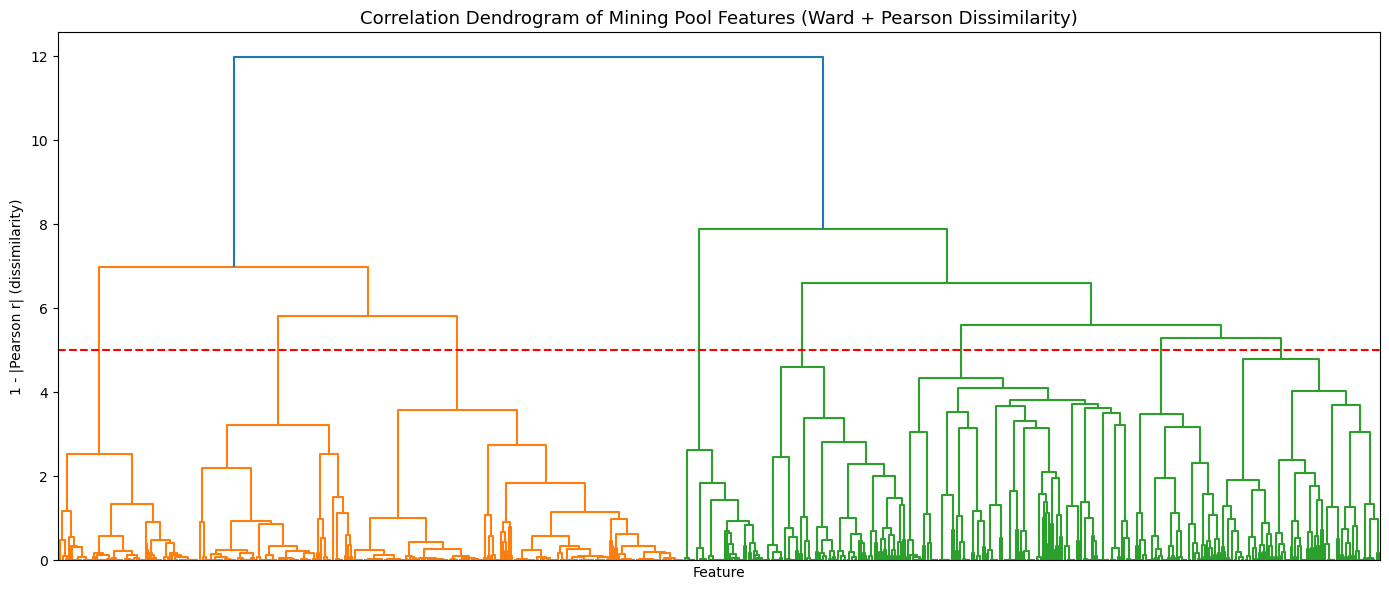

In [80]:
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title("Correlation Dendrogram of Mining Pool Features (Ward + Pearson Dissimilarity)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("1 - |Pearson r| (dissimilarity)")
plt.axhline(y=5, color='r', linestyle='--')
plt.tight_layout()
plt.show()

In [81]:
clusters_mining_pool = fcluster(Z, t=5, criterion="distance")

cluster_map_mining_pool = dict(zip(wide_mining.columns, clusters_mining_pool))


cluster_df_mining_pool = pd.DataFrame({
    "feature": wide_mining.columns,
    "cluster": clusters_mining_pool
})
cluster_df_mining_pool.head()

,feature,cluster
0,aaopool_1m_blocks_mined,6
1,aaopool_1m_dominance,6
2,aaopool_1w_blocks_mined,6
3,aaopool_1w_dominance,6
4,aaopool_1y_blocks_mined,3


In [82]:
cluster_df_mining_pool["cluster"].value_counts().sort_index()

cluster
1    140
2    153
3    328
4     83
5    138
6    227
7     85
8    158
Name: count, dtype: int64

In [83]:
n = cluster_df_mining_pool["cluster"].nunique()
clusters_mining_pool_dict = {}
for i in range(1, n+1):
    clusters_mining_pool_dict[i] = cluster_df_mining_pool[cluster_df_mining_pool["cluster"] == i]["feature"].tolist()


high_vif_mining_pool = {}  # store results outside loop

for i in range(1, n+1):
    print(f"\nCluster {i}:")
    
    # 1. Filter to cluster's metrics and pivot to wide format
    x = (
        train.filter(pl.col("metric").is_in(clusters_mining_pool_dict[i]))
        .pivot(index="day_utc", on="metric", values="value")
        .drop("day_utc")
        .to_pandas()
        .dropna()  # VIF can't handle nulls
    )
    
    if x.shape[1] < 2:
        print("  Skipping — need at least 2 features for VIF")
        continue

    # 2. Add constant and compute VIF
    X = add_constant(x)
    vif = pd.Series(
        [variance_inflation_factor(X.values, j) for j in range(X.shape[1])],
        index=X.columns
    )
    
    # 3. Drop the constant row and flag high VIF
    vif = vif.drop("const", errors="ignore")
    high_vif_mining_pool[i] = vif[vif > 10].index.tolist()
    
    print(vif.sort_values(ascending=False).to_string())
    print(f"\n  High VIF cols (>10): {high_vif_mining_pool[i]}")


Cluster 1:


/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


pool50btc_coinbase_cumulative                     inf
bcpoolio_coinbase_btc_cumulative         3.216857e+14
f2pool_subsidy_cumulative                9.285772e+13
braiinspool_coinbase_cumulative          4.816684e+13
tangpool_blocks_mined_cumulative         4.112876e+13
pool50btc_fee_cumulative                 1.597021e+13
mmpool_coinbase_btc_cumulative           1.130138e+13
pool50btc_subsidy_cumulative             7.097872e+12
hotpool_coinbase_cumulative              5.686363e+12
hashpool_coinbase_cumulative             5.458909e+12
antpool_coinbase_btc_cumulative          5.400000e+12
f2pool_subsidy_btc                       3.621713e+12
antpool_coinbase_cumulative              3.034771e+12
f2pool_subsidy_btc_cumulative            2.073958e+12
braiinspool_subsidy_cumulative           1.484132e+12
f2pool_coinbase_cumulative               1.425641e+12
kanopool_coinbase_cumulative             1.059920e+12
bcpoolio_subsidy_cumulative              6.343545e+11
tangpool_coinbase_cumulative

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


marapool_subsidy_cumulative                     inf
kucoinpool_coinbase_cumulative                  inf
ultimuspool_fee_usd                             inf
binancepool_coinbase_btc_cumulative             inf
ultimuspool_fee_cumulative                      inf
terrapool_coinbase_usd_cumulative               inf
marapool_fee_cumulative                         inf
marapool_coinbase_cumulative                    inf
marapool_coinbase_btc                           inf
kucoinpool_subsidy_btc                          inf
kucoinpool_fee_usd_cumulative                   inf
ultimuspool_coinbase_usd               9.007199e+15
pegapool_coinbase_usd_cumulative       9.007199e+15
pegapool_coinbase_usd                  9.007199e+15
ultimuspool_subsidy_usd_cumulative     9.007199e+15
binancepool_coinbase_cumulative        9.007199e+15
emcdpool_subsidy_cumulative            3.002400e+15
kucoinpool_coinbase_usd                3.002400e+15
emcdpool_fee_cumulative                3.002400e+15
marapool_coi

...

huobipool_fee_cumulative                2.836109e+11
huobipool_subsidy_cumulative            1.875250e+11
emcdpool_fee                            2.675896e+10
kanopool_coinbase_usd_cumulative        2.024922e+10
bwpool_subsidy_usd_cumulative           1.430945e+10
emcdpool_subsidy_btc                    1.275793e+10
hummerpool_coinbase_cumulative          9.741831e+09
sevenpool_blocks_mined_cumulative       8.603013e+09
sevenpool_subsidy_usd_cumulative        8.115179e+09
emcdpool_subsidy_usd                    8.010551e+09
aaopool_coinbase_btc_cumulative         7.842392e+09
canoepool_coinbase_usd_cumulative       7.342393e+09
hummerpool_fee_cumulative               7.129096e+09
braiinspool_fee_btc_cumulative          6.694687e+09
poolin_subsidy_btc_cumulative           6.493702e+09
batpool_coinbase_btc_cumulative         6.169560e+09
emcdpool_fee_btc                        4.952398e+09
dpool_coinbase_btc_cumulative           3.785323e+09
spiderpool_coinbase_usd_cumulative      3.3842

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


hashpool_fee_btc                          inf
sevenpool_24h_dominance                   inf
hashpool_coinbase_usd                     inf
sevenpool_coinbase                        inf
sevenpool_coinbase_btc                    inf
sevenpool_coinbase_usd                    inf
sevenpool_fee                             inf
sevenpool_fee_btc                         inf
sevenpool_fee_usd                         inf
sevenpool_subsidy                         inf
sevenpool_subsidy_btc                     inf
sevenpool_subsidy_usd                     inf
hashpool_subsidy_usd                      inf
hashpool_subsidy_btc                      inf
hashpool_subsidy                          inf
hashpool_fee_usd                          inf
hashpool_fee                              inf
hashpool_24h_blocks_mined                 inf
hashpool_24h_dominance                    inf
hashpool_blocks_mined                     inf
hashpool_coinbase                         inf
sevenpool_blocks_mined            

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


dpool_blocks_mined                         inf
dpool_fee_usd                              inf
braiinspool_coinbase_btc                   inf
hummerpool_24h_blocks_mined                inf
hummerpool_blocks_mined                    inf
hummerpool_fee_usd                         inf
hummerpool_fee                             inf
hummerpool_coinbase_usd                    inf
tigerpoolnet_blocks_mined         9.007199e+15
dpool_fee                         9.007199e+15
dpool_coinbase_btc                9.007199e+15
hummerpool_subsidy                9.007199e+15
hummerpool_subsidy_usd            9.007199e+15
tigerpoolnet_fee_btc              9.007199e+15
dpool_subsidy                     4.503600e+15
hummerpool_subsidy_btc            3.002400e+15
tigerpoolnet_subsidy              3.002400e+15
tigerpoolnet_fee                  3.002400e+15
hummerpool_coinbase_btc           3.002400e+15
dpool_coinbase_usd                2.251800e+15
tigerpoolnet_subsidy_btc          2.251800e+15
braiinspool_s

In [84]:
all_high_vif_mining_pool = [col for cols in high_vif_mining_pool.values() for col in cols]
len(all_high_vif_mining_pool)

1299

In [85]:
columns_to_drop_dict = {
    "columns_to_drop": all_high_vif_dca + all_high_vif_addrs + all_high_vif_cost_basis + all_high_vif_mining_pool
}
columns_to_drop = pd.DataFrame(columns_to_drop_dict)
columns_to_drop.to_csv("../columns_to_drop.csv", index=False)

### Checking the bitcoin crash 

In [34]:
some_cols = ["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio","price_200d_ema_ratio_2y_0sd_usd"]

In [43]:
crash_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2017, 1, 1)) & 
        ((pl.col("day_utc") <= pl.date(2018, 12, 31)))
    )
    .filter(pl.col("metric").is_in(["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio_2y_0sd_usd", "price_21d_sma"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [36]:
fig_price = px.line(crash_df.to_pandas(), x='day_utc', y='value', color='metric', title='Price Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_price.update_yaxes(matches=None)
fig_price.show()

### Market cap plot

In [45]:
cap_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["market_cap"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

cap_ratio_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["active_price","market_cap_growth_rate"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [46]:
px.line(cap_df.to_pandas(), x='day_utc', y='value', color='metric', title='Market Cap evolution over time')

In [47]:
px.line(cap_ratio_df.to_pandas(), x='day_utc', y='value', color='metric', title='Cap Ratio Metrics During Crash Period',facet_col="metric", facet_col_wrap=2)

In [48]:
rel_ratio_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["realized_cap_rel_to_own_market_cap","net_unrealized_pnl_rel_to_market_cap"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [49]:
fig_rel = px.line(rel_ratio_df.to_pandas(), x='day_utc', y='value', color='metric', title='Realized Cap Ratio Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_rel.update_yaxes(matches=None)
fig_rel.show()

### PNL plots

In [50]:
pnl_cols = ["net_unrealized_pnl_rel_to_market_cap","net_unrealized_pnl"]
pnl_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(pnl_cols))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [51]:
fig_pnl = px.line(pnl_df.to_pandas(), x='day_utc', y='value', color='metric', title='Net Unrealized PnL Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_pnl.update_yaxes(matches=None)
fig_pnl.show()

# Bitcoin price history with halving annotated

In [53]:
price_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["active_price"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [61]:
df = price_df.to_pandas()
df["day_utc"] = pd.to_datetime(df["day_utc"])

fig = px.line(df, x="day_utc", y="value", title="Bitcoin Price with Halving Events")


halving_dates = pd.to_datetime([

    "2012-11-28",

    "2016-07-09",

    "2020-05-11",

    "2024-04-20"

])

for date in halving_dates:

    fig.add_shape(

        type="line",

        x0=date,

        x1=date,

        y0=0,

        y1=1,

        xref="x",

        yref="paper",

        line=dict(color="red", dash="dash")

    )

    fig.add_annotation(

        x=date,

        y=1,

        xref="x",

        yref="paper",

        text="Halving",

        showarrow=False,

        yanchor="bottom"

    )
fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)
fig.show()

In [ ]:
cols = ["mvrv","sopr","nupl"]
combined_valuations = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(cols))
    .filter(pl.col("value").is_not_null())
    .collect()
)
combined_valuations_df = combined_valuations.to_pandas()

In [66]:
fig_combined = px.line(combined_valuations_df, x="day_utc", y="value", color="metric", title="Combined Valuation Metrics Over Time", facet_col="metric", facet_col_wrap=3)
fig_combined.update_yaxes(matches=None)
fig_combined.update_layout(
    template="plotly_white",
    hovermode="x unified"
)
fig_combined.show()